# <b><font size=7 color='orange'> Computer Assignment 4</font></b>

<b><font color="orange" size="6">Collaborators:</font></b><br>
<font color="orange" size="5">
  <i>
     Mehrad Liviyan - 810101501<br>
     Shayan Saeedi - 810101442
  </i>
</font>


## Load Dataset

In [13]:
from torchvision import datasets, transforms


transform  = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, ), (0.5, ))
])


train_ds = datasets.FashionMNIST('F_MNIST_data', train=True, download=True, transform=transform)
test_ds = datasets.FashionMNIST('F_MNIST_data', train=False, download=True, transform=transform)

In [14]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_loader))

print("Batch images shape:", images.shape)
print("Batch labels shape:", labels.shape)
print("Image shape:", images[0].shape)


Batch images shape: torch.Size([32, 1, 28, 28])
Batch labels shape: torch.Size([32])
Image shape: torch.Size([1, 28, 28])


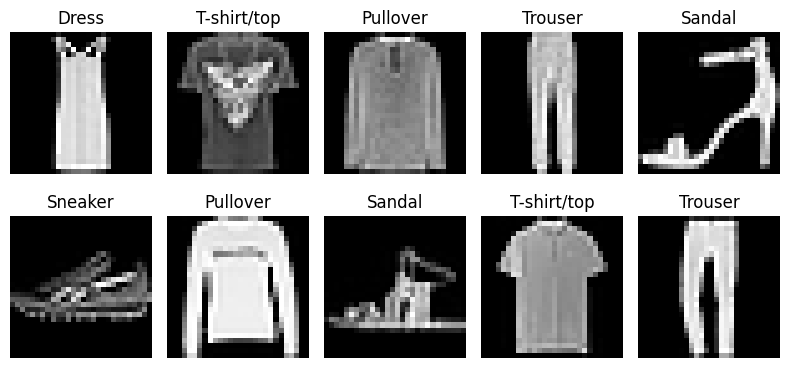

In [15]:
import matplotlib.pyplot as plt

classes = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
           'Sandal','Shirt','Sneaker','Bag','Ankle boot']

fig, axes = plt.subplots(2, 5, figsize=(8,4))
axes = axes.flatten()

for i in range(10):
    img = images[i].squeeze()
    label = labels[i]

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(classes[label])
    axes[i].axis('off')

plt.tight_layout()
plt.show()


<div dir="rtl">

در دیتاست Fashion-MNIST هر تصویر یک تصویر سیاه‌وسفید با ابعاد ۲۸×۲۸ پیکسل است که در قالب تانسوری با شکل ‌(1, 28, 28) نگهداری می‌شود؛ عدد ۱ نشان‌دهنده تعداد کانال‌هاست چون تصویر رنگی نیست. هنگام استفاده از شبکه‌های عصبی مبتنی بر لایه‌های کاملاً متصل (Fully Connected) ورودی باید به صورت یک بردار یک‌بعدی از ویژگی‌ها باشد، نه یک ماتریس دوبعدی. بنابراین لازم است تصویر را به شکل یک بردار ۷۸۴‌تایی (۲۸×۲۸) تخت‌سازی یا Flatten کنیم تا هر پیکسل به‌عنوان یک ویژگی مجزا به مدل داده شود. البته در شبکه‌های کانولوشنی (CNN) نیازی به Flatten در ابتدا نیست، چون آن‌ها می‌توانند ساختار فضایی دوبعدی تصویر را مستقیماً پردازش کنند.

## Model

In [16]:
import torch
import torch.nn as nn


input_dim = images[0].shape

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


model = SimpleNN()


print(model)
print("Total number of parameters: ", sum(p.numel() for p in model.parameters()))


SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)
Total number of parameters:  235146


<div dir="rtl">

توضیح ساختار مدل:

Flatten:

ورودی به مدل یک تصویر ۲۸×۲۸ پیکسل است. لایه Flatten این تصویر را به یک بردار از ۷۸۴ عنصر تبدیل می‌کند.

لایه Fully Connected اول (fc1):

این لایه ۷۸۴ ویژگی ورودی را به ۲۵۶ نرون متصل می‌کند.

تعداد پارامترهای این لایه:

وزن‌ها:
784
×
256
=
200
,
704
784×256=200,704

بایاس‌ها:
256
256

مجموع:
200
,
960
200,960

لایه Fully Connected دوم (fc2):

لایه دوم ۲۵۶ نرون ورودی را به ۱۲۸ نرون متصل می‌کند.

تعداد پارامترهای این لایه:

وزن‌ها:
256
×
128
=
32
,
768
256×128=32,768

بایاس‌ها:
128
128

مجموع:
32
,
896
32,896

لایه Fully Connected سوم (fc3):

این لایه ۱۲۸ نرون ورودی را به ۱۰ نرون خروجی متصل می‌کند (برای دسته‌بندی ۱۰ کلاس).

تعداد پارامترهای این لایه:

وزن‌ها:
128
×
10
=
1
,
280
128×10=1,280

بایاس‌ها:
10
10

مجموع:
1
,
290
1,290

کل پارامترها:

مجموع کل پارامترهای مدل:

200,960 + 32,896 + 1,290 = 235,146 پارامتر

توضیح اجزای مدل:

Flatten: به مدل کمک می‌کند تا تصاویر دوبعدی را به یک بردار یک‌بعدی تبدیل کند که قابل پردازش توسط لایه‌های fully connected باشد.

Fully Connected Layers: این لایه‌ها ویژگی‌های ورودی را با وزن‌ها و بایاس‌ها ترکیب می‌کنند تا به ویژگی‌های پیچیده‌تر پردازش کنند. لایه‌های fc1 و fc2 با استفاده از ReLU فعال‌سازی می‌شوند تا مدل از غیرخطی بودن برخوردار باشد.

Laye Output: لایه خروجی تعداد نرون‌های ۱۰ است که برای دسته‌بندی ۱۰ کلاس کافی است. این لایه به طور خودکار از CrossEntropyLoss برای انجام Softmax استفاده می‌کند.


## Loss & Optimizer

In [17]:
import torch.optim as optim


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

<div dir="rtl" >

CrossEntropyLoss:

nn.CrossEntropyLoss() یک تابع هزینه است که برای مسائل طبقه‌بندی چندکلاسه طراحی شده است. این تابع به طور خودکار از softmax برای نرمال‌سازی پیش‌بینی‌های مدل به مقادیر احتمال (در بازه 0 تا 1) استفاده می‌کند و سپس log likelihood منفی را محاسبه می‌کند. هدف مدل این است که پیش‌بینی‌های خود را برای هر کلاس به نزدیک‌ترین مقدار ممکن به 1 (در صورت درست بودن کلاس) و دیگر کلاس‌ها را به نزدیک‌ترین مقدار ممکن به 0 نزدیک کند.

این تابع نیازی به اعمال Softmax دستی ندارد چون در درون خود این کار را انجام می‌دهد.

مناسب برای دسته‌بندی با چند کلاس است و برای هر نمونه، یک مقدار پیش‌بینی احتمال برای هر کلاس خروجی تولید می‌کند.

Adam:

Adam یک الگوریتم بهینه‌سازی است که به صورت خودکار گام‌های بهینه را برای به‌روزرسانی وزن‌ها تعیین می‌کند. این بهینه‌ساز از گام‌های بهینه و میانگین متحرک برای سرعت بخشیدن به یادگیری استفاده می‌کند و معمولا برای مشکلات پیچیده‌تر و دسته‌بندی‌های چندکلاسه مناسب است.

## Train

In [18]:
num_epochs = 10

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(100 * correct_predictions / total_samples)
    model.eval()
    correct_predictions_test = 0
    total_samples_test = 0
    running_test_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_samples_test += labels.size(0)
            correct_predictions_test += (predicted == labels).sum().item()

    test_loss = running_test_loss / len(test_loader)
    test_accuracy = 100 * correct_predictions_test / total_samples_test

    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Train Accuracy: {train_accuracies[-1]:.2f}%, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

print(f"Final Train Accuracy: {100 * correct_predictions / total_samples:.2f}%")
print(f"Final Test Accuracy: {test_accuracy:.2f}%")


Epoch 1/10, Train Loss: 0.4825, Train Accuracy: 82.16%, Test Loss: 0.4197, Test Accuracy: 84.89%
Epoch 2/10, Train Loss: 0.3711, Train Accuracy: 86.33%, Test Loss: 0.3699, Test Accuracy: 86.74%
Epoch 3/10, Train Loss: 0.3339, Train Accuracy: 87.66%, Test Loss: 0.3634, Test Accuracy: 86.84%
Epoch 4/10, Train Loss: 0.3064, Train Accuracy: 88.59%, Test Loss: 0.3527, Test Accuracy: 87.17%
Epoch 5/10, Train Loss: 0.2882, Train Accuracy: 89.31%, Test Loss: 0.3615, Test Accuracy: 87.17%
Epoch 6/10, Train Loss: 0.2709, Train Accuracy: 89.94%, Test Loss: 0.3377, Test Accuracy: 88.17%
Epoch 7/10, Train Loss: 0.2575, Train Accuracy: 90.28%, Test Loss: 0.3452, Test Accuracy: 88.18%
Epoch 8/10, Train Loss: 0.2459, Train Accuracy: 90.69%, Test Loss: 0.3468, Test Accuracy: 87.76%
Epoch 9/10, Train Loss: 0.2309, Train Accuracy: 91.25%, Test Loss: 0.3447, Test Accuracy: 88.54%
Epoch 10/10, Train Loss: 0.2224, Train Accuracy: 91.55%, Test Loss: 0.3384, Test Accuracy: 88.44%
Final Train Accuracy: 91.55%


## Evaluate

Test Accuracy: 88.44%
Missmatched samples:


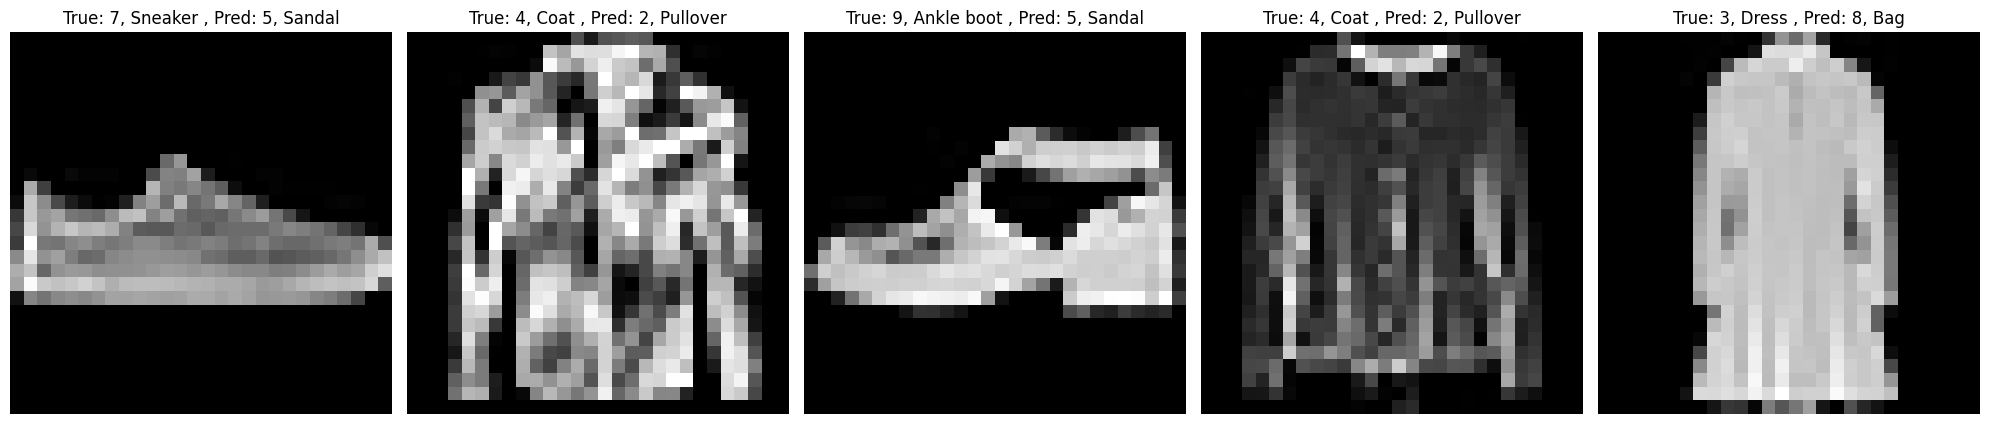

Correctmatched samples:


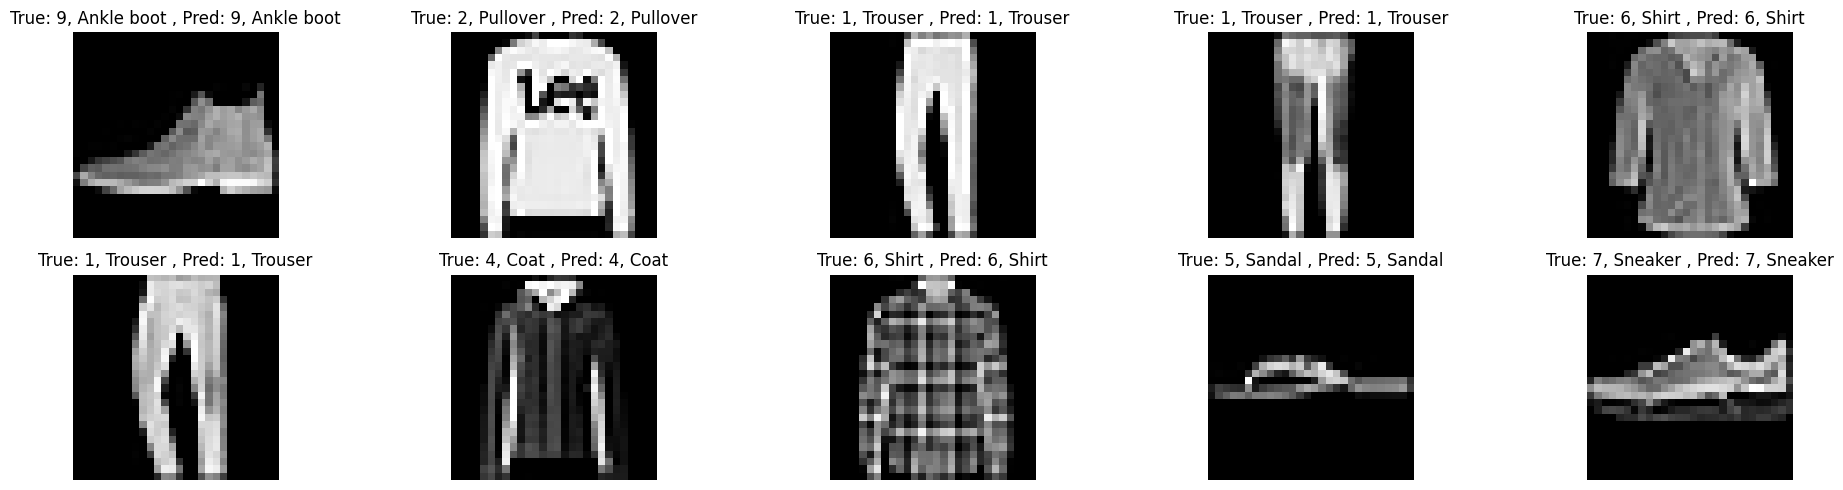

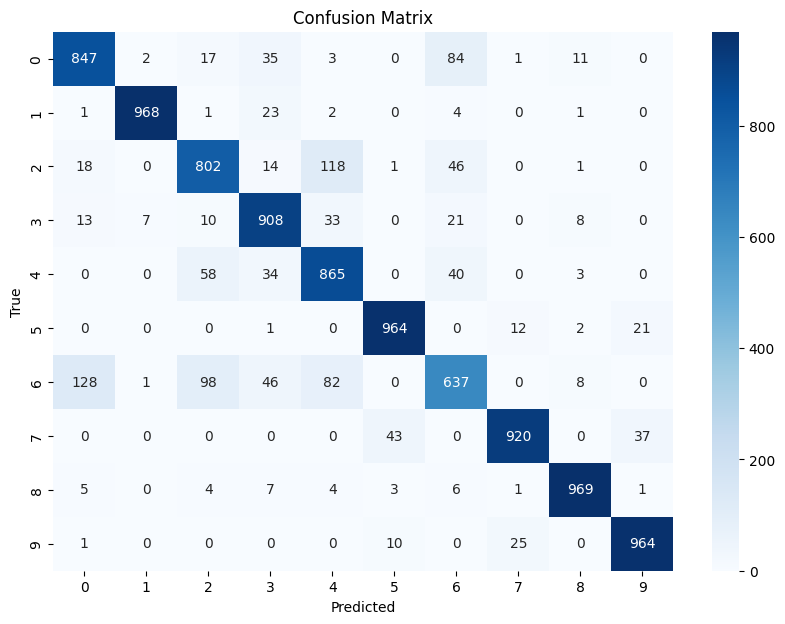

Class 0, T-shirt/top: 153 misclassifications
Class 1, Trouser: 32 misclassifications
Class 2, Pullover: 198 misclassifications
Class 3, Dress: 92 misclassifications
Class 4, Coat: 135 misclassifications
Class 5, Sandal: 36 misclassifications
Class 6, Shirt: 363 misclassifications
Class 7, Sneaker: 80 misclassifications
Class 8, Bag: 31 misclassifications
Class 9, Ankle boot: 36 misclassifications


In [28]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()
correct_predictions = 0
total_samples = 0
misclassified_images = []
misclassified_labels = []
misclassified_preds = []
correct_images = []
correct_labels = []
correct_preds = []

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

        correct_mask = predicted == labels
        correct_images.append(images[correct_mask])
        correct_labels.append(labels[correct_mask])
        correct_preds.append(predicted[correct_mask])

        misclassified_mask = predicted != labels
        misclassified_images.append(images[misclassified_mask])
        misclassified_labels.append(labels[misclassified_mask])
        misclassified_preds.append(predicted[misclassified_mask])

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct_predictions / total_samples
print(f"Test Accuracy: {accuracy:.2f}%")



print("Missmatched samples:")
num_misclassified = min(len(misclassified_images[0]), 10)

fig, axes = plt.subplots(1, num_misclassified, figsize=(20, 5))
axes = axes.flatten()

for i in range(num_misclassified):
    img = misclassified_images[0][i].squeeze()
    true_label = misclassified_labels[0][i].item()
    predicted_label = misclassified_preds[0][i].item()

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {true_label}, {classes[true_label]} , Pred: {predicted_label}, {classes[predicted_label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


print("Correctmatched samples:")

num_correct = min(len(correct_images[0]), 10)
fig, axes = plt.subplots(2, num_correct//2, figsize=(20, 5))
axes = axes.flatten()
for i in range(num_correct):
    img = correct_images[0][i].squeeze()
    true_label = correct_labels[0][i].item()
    predicted_label = correct_preds[0][i].item()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {true_label}, {classes[true_label]} , Pred: {predicted_label}, {classes[predicted_label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

conf_matrix = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

misclassified_labels = torch.cat(misclassified_labels)
misclassified_preds = torch.cat(misclassified_preds)

class_wise_misclassifications = {}
for i in range(10):
    true_class_mask = misclassified_labels == i
    predicted_class_mask = misclassified_preds == i
    misclassified_count = true_class_mask.sum().item()
    class_wise_misclassifications[i] = misclassified_count

for class_id, miscount in class_wise_misclassifications.items():
    print(f"Class {class_id}, {classes[class_id]}: {miscount} misclassifications")


<div dir="rtl">

درسته که مدل دقت خوبی داره (88.44%)، اما هنوز بعضی لباس‌ها رو درست شناسایی نمی‌کنه. مثلاً، Shirt با 363 اشتباه بیشترین مشکلات رو داره. این می‌تونه به این خاطر باشه که مدل بین Shirt و لباس‌های دیگه مثل T-shirt یا Pullover نمی‌تونه تمایز زیادی بذاره. همینطور Pullover با 198 اشتباه هم یکی دیگه از دسته‌هاست که مدل نمی‌تونه درست تشخیص بده.

از طرف دیگه، لباس‌هایی مثل Trouser (32 اشتباه) یا Bag (31 اشتباه) رو مدل به راحتی تشخیص می‌ده. این لباس‌ها شاید ویژگی‌های مشخص‌تری دارن که مدل راحت‌تر می‌تونه شناساییشون کنه.

در نهایت، مدل بیشتر با لباس‌هایی مثل Coat (135 اشتباه) و Sneaker (80 اشتباه) مشکل داره. احتمالاً این‌ها شباهت‌های زیادی به لباس‌های دیگه دارن یا ویژگی‌های خاصی ندارن که مدل بتونه درست تشخیص بده.

در کل، مدل دقت خوبی داره، ولی برای لباس‌هایی که ویژگی‌های پیچیده‌تری دارن مثل Shirt یا Pullover، نیاز به بهبود بیشتر داره.

<div dir="rtl">

## Plot Loss & Acc

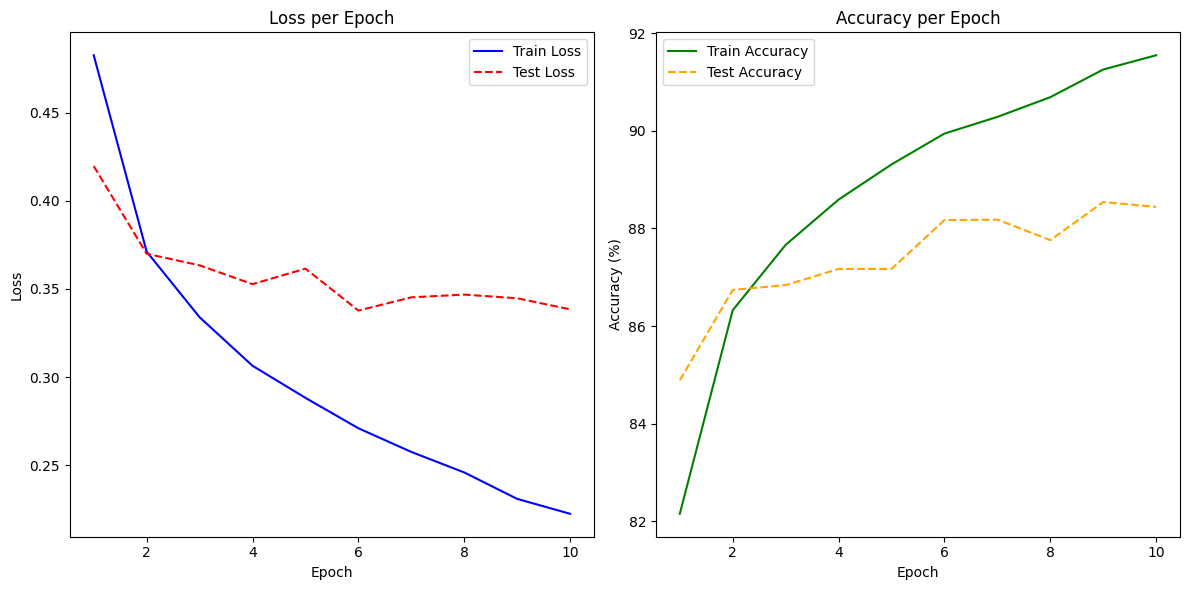

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, num_epochs + 1), test_losses, label='Test Loss', color='red', linestyle='dashed')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy', color='orange', linestyle='dashed')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy per Epoch')
plt.legend()

plt.tight_layout()
plt.show()


<div dir="rtl">

تقریبا در ephoc 7 میشه دید که داریم به سمت یه overfit میرویم چون loss برای test داره بیشتر یا ثابت می شود ولی برای train داره کم تر میشه که نشون دهنده این است که مدل داره جواب ها رو برای train حفظ می کند و دیگر یاد نمی گیرد پس می توان گفت داره از ephoc هفتم یه overfit اتفاق می افتد.

## Add Dropout

In [30]:
import torch.nn as nn

class ModelWithDropout(nn.Module):
    def __init__(self):
        super(ModelWithDropout, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = ModelWithDropout()


print(model)
print("Total number of parameters: ", sum(p.numel() for p in model.parameters()))

ModelWithDropout(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)
Total number of parameters:  235146


In [31]:
import torch.optim as optim


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [32]:
num_epochs = 10

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(100 * correct_predictions / total_samples)
    model.eval()
    correct_predictions_test = 0
    total_samples_test = 0
    running_test_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_samples_test += labels.size(0)
            correct_predictions_test += (predicted == labels).sum().item()

    test_loss = running_test_loss / len(test_loader)
    test_accuracy = 100 * correct_predictions_test / total_samples_test

    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_losses[-1]:.4f}, Train Accuracy: {train_accuracies[-1]:.2f}%, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

print(f"Final Train Accuracy: {100 * correct_predictions / total_samples:.2f}%")
print(f"Final Test Accuracy: {test_accuracy:.2f}%")


Epoch 1/10, Train Loss: 0.5855, Train Accuracy: 78.69%, Test Loss: 0.4380, Test Accuracy: 83.94%
Epoch 2/10, Train Loss: 0.4708, Train Accuracy: 82.90%, Test Loss: 0.4393, Test Accuracy: 83.88%
Epoch 3/10, Train Loss: 0.4377, Train Accuracy: 84.08%, Test Loss: 0.4023, Test Accuracy: 85.15%
Epoch 4/10, Train Loss: 0.4178, Train Accuracy: 84.87%, Test Loss: 0.3836, Test Accuracy: 85.86%
Epoch 5/10, Train Loss: 0.4037, Train Accuracy: 85.28%, Test Loss: 0.3849, Test Accuracy: 86.28%
Epoch 6/10, Train Loss: 0.3946, Train Accuracy: 85.59%, Test Loss: 0.3755, Test Accuracy: 86.05%
Epoch 7/10, Train Loss: 0.3837, Train Accuracy: 85.97%, Test Loss: 0.3660, Test Accuracy: 86.56%
Epoch 8/10, Train Loss: 0.3734, Train Accuracy: 86.17%, Test Loss: 0.3647, Test Accuracy: 86.90%
Epoch 9/10, Train Loss: 0.3676, Train Accuracy: 86.58%, Test Loss: 0.3573, Test Accuracy: 87.09%
Epoch 10/10, Train Loss: 0.3616, Train Accuracy: 86.61%, Test Loss: 0.3562, Test Accuracy: 86.87%
Final Train Accuracy: 86.61%


Test Accuracy: 86.87%
Missmatched samples:


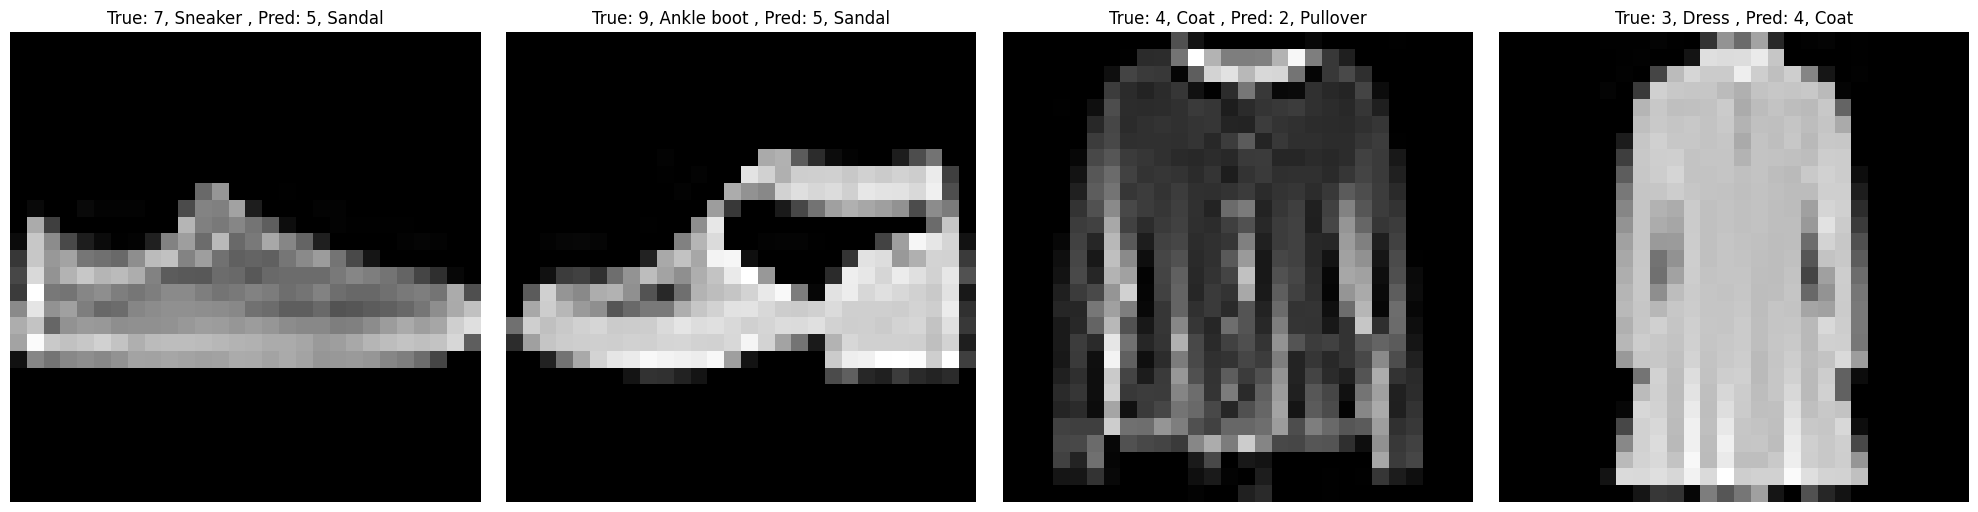

Correctmatched samples:


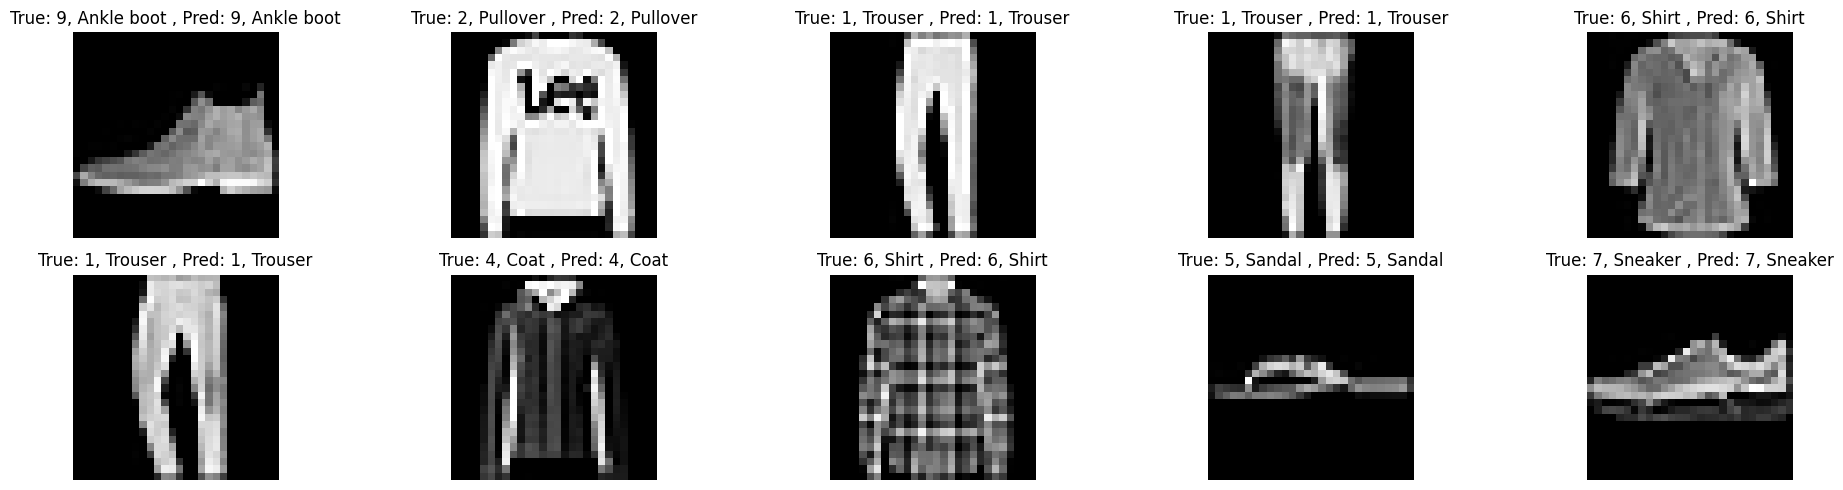

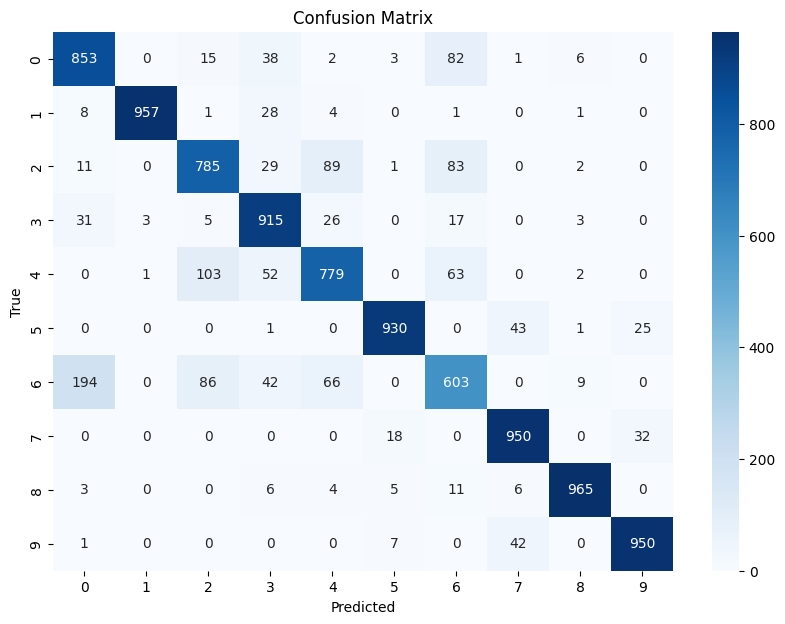

Class 0, T-shirt/top: 147 misclassifications
Class 1, Trouser: 43 misclassifications
Class 2, Pullover: 215 misclassifications
Class 3, Dress: 85 misclassifications
Class 4, Coat: 221 misclassifications
Class 5, Sandal: 70 misclassifications
Class 6, Shirt: 397 misclassifications
Class 7, Sneaker: 50 misclassifications
Class 8, Bag: 35 misclassifications
Class 9, Ankle boot: 50 misclassifications


In [33]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.eval()
correct_predictions = 0
total_samples = 0
misclassified_images = []
misclassified_labels = []
misclassified_preds = []
correct_images = []
correct_labels = []
correct_preds = []

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

        correct_mask = predicted == labels
        correct_images.append(images[correct_mask])
        correct_labels.append(labels[correct_mask])
        correct_preds.append(predicted[correct_mask])

        misclassified_mask = predicted != labels
        misclassified_images.append(images[misclassified_mask])
        misclassified_labels.append(labels[misclassified_mask])
        misclassified_preds.append(predicted[misclassified_mask])

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = 100 * correct_predictions / total_samples
print(f"Test Accuracy: {accuracy:.2f}%")



print("Missmatched samples:")
num_misclassified = min(len(misclassified_images[0]), 10)

fig, axes = plt.subplots(1, num_misclassified, figsize=(20, 5))
axes = axes.flatten()

for i in range(num_misclassified):
    img = misclassified_images[0][i].squeeze()
    true_label = misclassified_labels[0][i].item()
    predicted_label = misclassified_preds[0][i].item()

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {true_label}, {classes[true_label]} , Pred: {predicted_label}, {classes[predicted_label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


print("Correctmatched samples:")

num_correct = min(len(correct_images[0]), 10)
fig, axes = plt.subplots(2, num_correct//2, figsize=(20, 5))
axes = axes.flatten()
for i in range(num_correct):
    img = correct_images[0][i].squeeze()
    true_label = correct_labels[0][i].item()
    predicted_label = correct_preds[0][i].item()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {true_label}, {classes[true_label]} , Pred: {predicted_label}, {classes[predicted_label]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

conf_matrix = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

misclassified_labels = torch.cat(misclassified_labels)
misclassified_preds = torch.cat(misclassified_preds)

class_wise_misclassifications = {}
for i in range(10):
    true_class_mask = misclassified_labels == i
    predicted_class_mask = misclassified_preds == i
    misclassified_count = true_class_mask.sum().item()
    class_wise_misclassifications[i] = misclassified_count

for class_id, miscount in class_wise_misclassifications.items():
    print(f"Class {class_id}, {classes[class_id]}: {miscount} misclassifications")


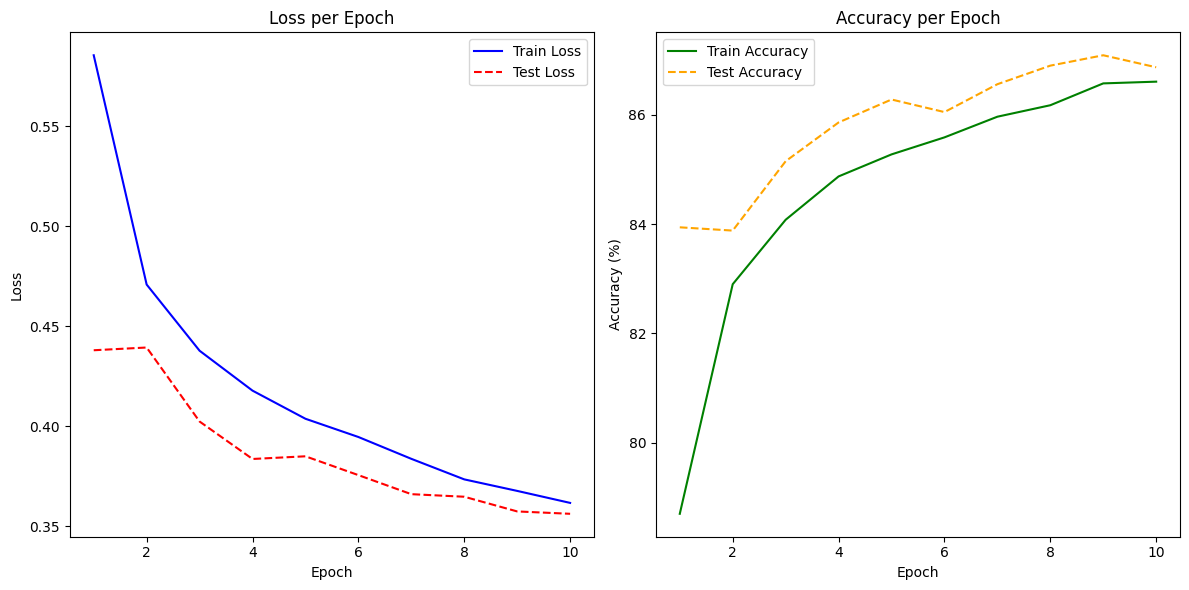

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, num_epochs + 1), test_losses, label='Test Loss', color='red', linestyle='dashed')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy', color='green')
plt.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy', color='orange', linestyle='dashed')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy per Epoch')
plt.legend()

plt.tight_layout()
plt.show()


<div dir="rtl">

اگر دقت کنیم با اضافه کردن dropout با اینکه درصد تست ما تقریبا 1 تا 2 درصد کاهش داشت ولی با این حال باعث شد overfirt بدست آمده یا احتمالی از بین برود چون هم train و test هر دو به یه دقت برابری رسیدن تقریبا و باز هم با ephoc های بیشتر قابلیت رشد داشتن و دوم اینکه اگر به نمودار loss و acc دقت کنیم دو تایی با هم همروند هستند و به ترتیب در حال کاهش و افزایش هستند که خودش نشون میده که ما فعلا درگیر overfit نشدیم و هنوز هم مدل قابلیت رشد کردن داره.